# DVM-CAR (front-view) — классификация цвета автомобиля

**Цель лабораторной:** обучить 3 классификатора для предсказания **цвета автомобиля** по фронтальному изображению из DVM-CAR (quality-checked front-view subset) и сравнить их по **F1_macro**, добиться **F1_macro > 0.8**.

**Что сделано в ноутбуке:**
1) **Своя модель:** самописный **ResNet-18**.
2) **2 предобученные модели (ImageNet) + fine-tune:** `ResNet50`, `MobileNetV3-Large`.
3) В ноутбуке есть: обоснование аугментаций + визуальная проверка, графики обучения (loss/F1 на train и val), отчёты (classification report, confusion matrix) и ручной инференс на картинках.

In [1]:
import os, random, math, time, json
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from tqdm.auto import tqdm

torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

print("device:", device)


/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /usr/local/lib/python3.10/dist-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


device: cuda


## 1) Данные: скачать/распаковать и указать путь

Мы используем **quality-checked front-view subset** из DVM-CAR (порядка **61,827** фронтальных изображений).

После того как  указали `DATA_ROOT`, ниже мы:
- индексируем датасет,
- нормализуем/объединяем названия цветов (если встречаются варианты),
- фильтруем слишком редкие классы (чтобы F1_macro был честным и стабильным),
- делаем train/val/test со стратификацией по цвету.


In [3]:
DATA_ROOT = Path(os.environ.get("auto_dataset", "./auto_dataset")).resolve()
DATA_ROOT

PosixPath('/home/jupyter/project/auto_dataset')

In [4]:
def download_file(url: str, dst_path: Path, chunk_size: int = 1 << 20):
    import requests
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("Content-Length", "0"))
        pbar = tqdm(total=total, unit="B", unit_scale=True, desc=dst_path.name)
        with open(dst_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
        pbar.close()

def unzip(zip_path: Path, dst_dir: Path):
    import zipfile
    dst_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(dst_dir)

AUTO_DOWNLOAD = False

FRONT_ZIP_URL = os.environ.get("DVM_FRONT_ZIP_URL", "https://figshare.com/ndownloader/files/34792480")
FRONT_ZIP_PATH = Path("./dvm_front_view.zip").resolve()

if AUTO_DOWNLOAD and (not DATA_ROOT.exists() or not any(DATA_ROOT.rglob("*.jpg"))):
    if not FRONT_ZIP_PATH.exists():
        download_file(FRONT_ZIP_URL, FRONT_ZIP_PATH)
    unzip(FRONT_ZIP_PATH, DATA_ROOT)

len(list(DATA_ROOT.rglob("*.jpg"))), str(DATA_ROOT)

(61827, '/home/jupyter/project/auto_dataset')

## 2) Индексация датасета и анализ распределения классов

In [5]:
import re
from pathlib import Path
import pandas as pd

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

# Нормализация имён цветов: в датасете могут встречаться варианты написания.
_COLOUR_ALIASES = {
    "grey": "Gray",
    "gray": "Gray",
    "silver": "Silver",
    "white": "White",
    "black": "Black",
    "red": "Red",
    "blue": "Blue",
    "green": "Green",
    "yellow": "Yellow",
    "orange": "Orange",
    "brown": "Brown",
    "beige": "Beige",
    "purple": "Purple",
    "pink": "Pink",
    "gold": "Gold",
}

def normalize_colour(s: str) -> str:
    s0 = str(s).strip().replace("_", " ").replace("-", " ")
    s0 = re.sub(r"\s+", " ", s0)
    key = s0.lower()
    return _COLOUR_ALIASES.get(key, s0)

def build_index(root: Path) -> pd.DataFrame:
    '''
    Индексация изображений.
    Пытаемся извлечь (brand, model, year, colour, genmodel_id, adv_id, img_idx) из имени файла.
    '''
    rows = []
    for p in root.rglob("*"):
        if not p.is_file() or p.suffix.lower() not in IMG_EXTS:
            continue

        brand = model = year = colour = None
        genmodel_id = adv_id = img_idx = None

        stem = p.stem  # имя без расширения
        if "$$" in stem:
            parts = stem.split("$$")
        elif "$" in stem:
            parts = stem.split("$")
        else:
            parts = []

        if len(parts) >= 4:
            brand, model, year, colour = [x.strip() for x in parts[:4]]
            if len(parts) >= 7:
                genmodel_id, adv_id, img_idx = [x.strip() for x in parts[4:7]]

        colour = normalize_colour(colour)

        if str(colour).strip().lower() == "unlisted":
            continue

        rows.append({
            "path": str(p),
            "brand": brand,
            "model": model,
            "year": year,
            "colour": colour,
            "genmodel_id": genmodel_id,
            "adv_id": adv_id,
            "img_idx": img_idx,
        })

    df = pd.DataFrame(rows).dropna(subset=["path", "colour"])
    df = df.drop_duplicates(subset=["path"]).reset_index(drop=True)
    return df

df = build_index(DATA_ROOT)

print(df.sample(5)[["path","brand","model","year","colour","genmodel_id","adv_id"]])
print("\nTop-20 colours:\n", df["colour"].value_counts().head(20))
print("\nTotal images:", len(df), " | unique colours:", df["colour"].nunique())


                                                    path  ... adv_id
12136  /home/jupyter/project/auto_dataset/confirmed_f...  ...   1239
41478  /home/jupyter/project/auto_dataset/confirmed_f...  ...    695
20972  /home/jupyter/project/auto_dataset/confirmed_f...  ...      5
8426   /home/jupyter/project/auto_dataset/confirmed_f...  ...    124
1608   /home/jupyter/project/auto_dataset/confirmed_f...  ...    116

[5 rows x 7 columns]

Top-20 colours:
 Black          14317
Gray            9474
White           9395
Blue            8483
Silver          7770
Red             6095
Brown            911
Green            777
Yellow           667
Beige            600
Orange           559
Purple           362
Bronze           329
Gold             217
Multicolour      196
Pink              87
Turquoise         26
Maroon            26
Burgundy           9
Magenta            9
Name: colour, dtype: int64

Total images: 60311  | unique colours: 22


Black          14317
Gray            9474
White           9395
Blue            8483
Silver          7770
Red             6095
Brown            911
Green            777
Yellow           667
Beige            600
Orange           559
Purple           362
Bronze           329
Gold             217
Multicolour      196
Pink              87
Turquoise         26
Maroon            26
Burgundy           9
Magenta            9
Navy               1
Indigo             1
Name: colour, dtype: int64

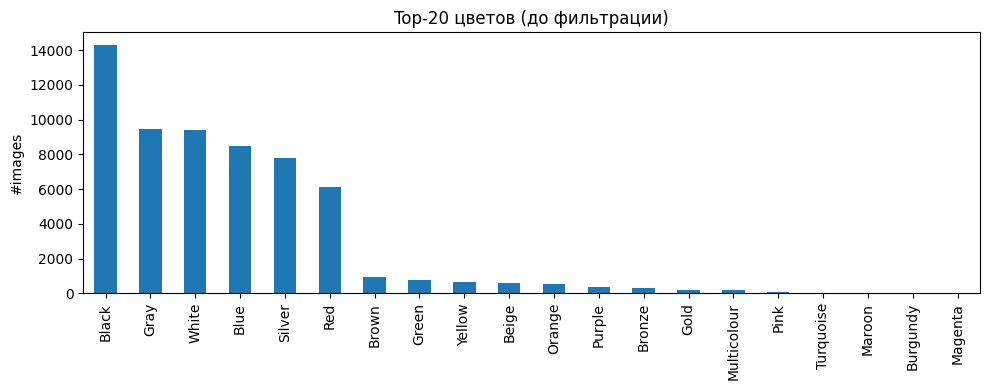

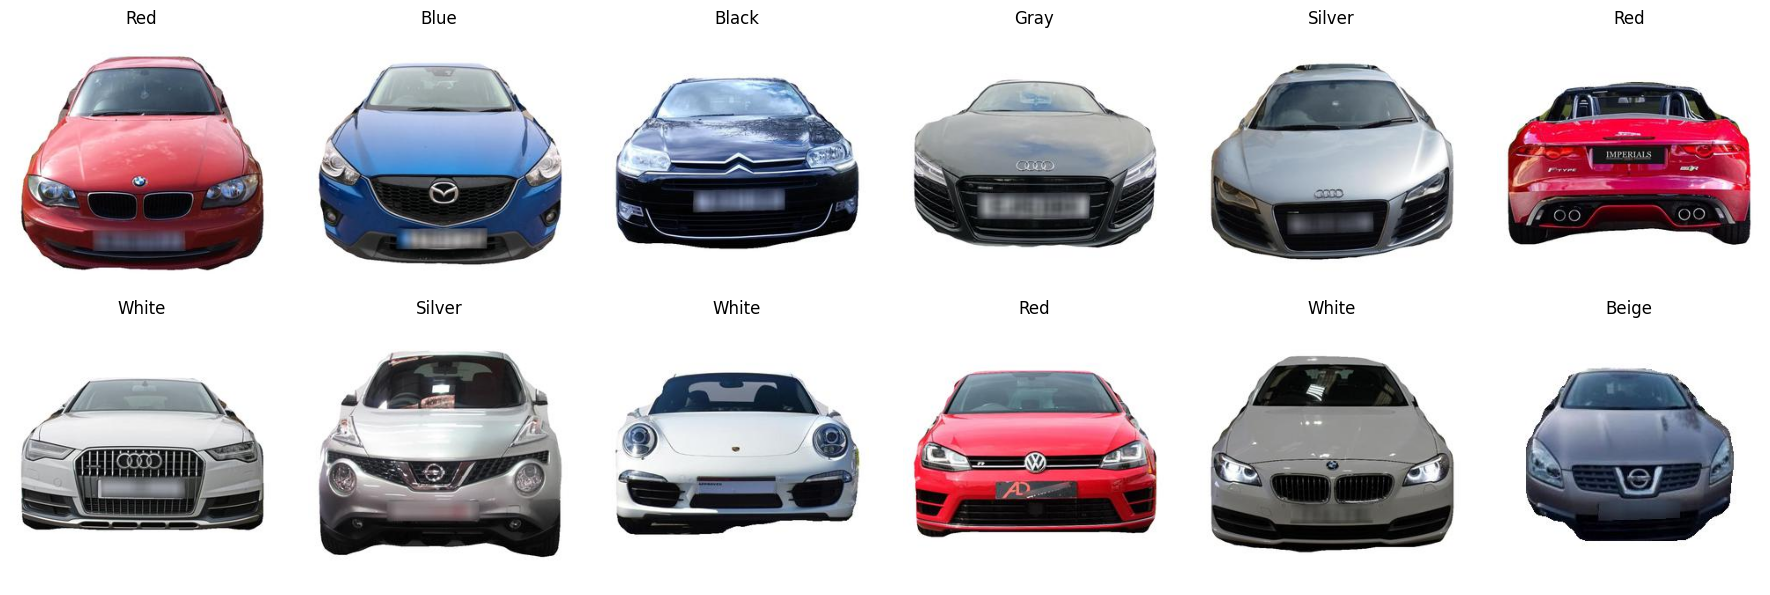

In [6]:
from IPython.display import display
import matplotlib.pyplot as plt

# Распределение цветов (до фильтрации)
counts = df["colour"].value_counts()
display(counts.head(30))

plt.figure(figsize=(10,4))
counts.head(20).plot(kind="bar")
plt.title("Top-20 цветов (до фильтрации)")
plt.ylabel("#images")
plt.tight_layout()
plt.show()

# Визуальный sanity-check: несколько случайных картинок из датасета
from PIL import Image
import random

def show_random_images(frame: pd.DataFrame, n: int = 12):
    frame = frame.sample(n=min(n, len(frame)), random_state=SEED)
    cols = 6
    rows = (len(frame) + cols - 1) // cols
    plt.figure(figsize=(cols*3, rows*3))
    for i, (_, r) in enumerate(frame.iterrows(), 1):
        img = Image.open(r["path"]).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(r["colour"])
    plt.tight_layout()
    plt.show()

show_random_images(df, n=12)


Classes kept: 10


Black     14317
Gray       9474
White      9395
Blue       8483
Silver     7770
Red        6095
Brown       911
Green       777
Yellow      667
Beige       600
Name: colour, dtype: int64

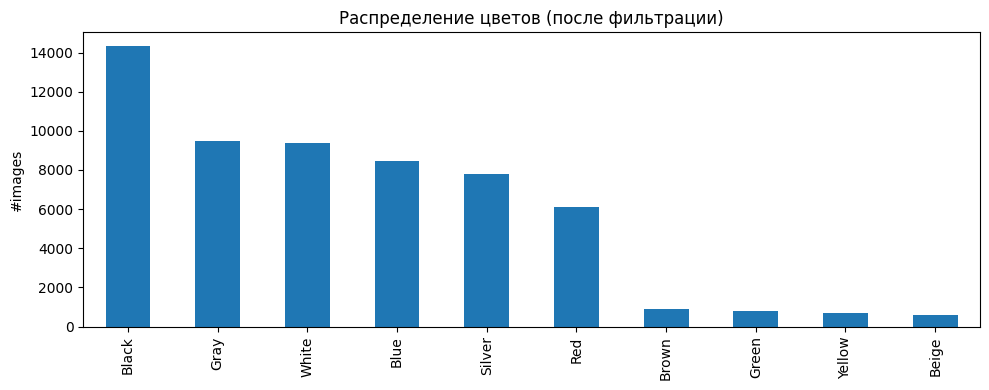

In [7]:
from IPython.display import display

MAX_CLASSES = 10              # ограничиваемся top-10 по частоте

counts = df["colour"].value_counts()
kept = counts.head(MAX_CLASSES).index.tolist()

df_f = df[df["colour"].isin(kept)].copy()

# фиксируем порядок меток
kept = df_f["colour"].value_counts().index.tolist()
df_f["colour"] = pd.Categorical(df_f["colour"], categories=kept)

colour2id = {c:i for i,c in enumerate(kept)}
id2colour = {i:c for c,i in colour2id.items()}
df_f["label"] = df_f["colour"].map(colour2id).astype(int)

print("Classes kept:", len(kept))
display(df_f["colour"].value_counts())

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
df_f["colour"].value_counts().plot(kind="bar")
plt.title("Распределение цветов (после фильтрации)")
plt.ylabel("#images")
plt.tight_layout()
plt.show()

n_classes = len(kept)
df12 = df_f


## 3) Stratified split: train/val/test

Так как официального split нет, делаем `80/10/10` стратифицировано по цвету.

train / val / test sizes: 46791 5849 5849
overlap train∩val: 0
overlap train∩test: 0
overlap val∩test: 0


,train,val,test
Black,11453,1432,1432
Gray,7579,948,947
White,7516,940,939
Blue,6786,848,849
Silver,6216,777,777
Red,4876,609,610
Brown,729,91,91
Green,622,77,78
Yellow,534,67,66
Beige,480,60,60


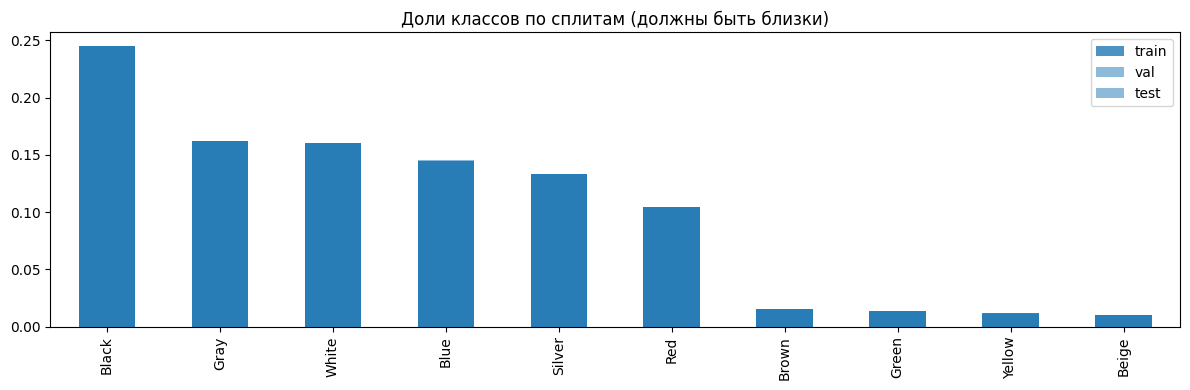

In [8]:
from IPython.display import display
from sklearn.model_selection import train_test_split

# 80/10/10 стратифицировано по label
train_df, tmp_df = train_test_split(
    df12, test_size=0.2, random_state=SEED, stratify=df12["label"]
)
val_df, test_df = train_test_split(
    tmp_df, test_size=0.5, random_state=SEED, stratify=tmp_df["label"]
)

print("train / val / test sizes:", len(train_df), len(val_df), len(test_df))

# Проверка отсутствия утечки (по путям файлов)
tr_set = set(train_df["path"])
va_set = set(val_df["path"])
te_set = set(test_df["path"])
print("overlap train∩val:", len(tr_set & va_set))
print("overlap train∩test:", len(tr_set & te_set))
print("overlap val∩test:", len(va_set & te_set))
assert len(tr_set & va_set) == 0 and len(tr_set & te_set) == 0 and len(va_set & te_set) == 0

# Распределение классов по сплитам (sanity-check)
import pandas as pd
dist = pd.DataFrame({
    "train": train_df["colour"].value_counts(),
    "val": val_df["colour"].value_counts(),
    "test": test_df["colour"].value_counts(),
}).fillna(0).astype(int)

display(dist)

# можно визуализировать:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
(dist["train"] / dist["train"].sum()).plot(kind="bar", alpha=0.8, label="train")
(dist["val"] / dist["val"].sum()).plot(kind="bar", alpha=0.5, label="val")
(dist["test"] / dist["test"].sum()).plot(kind="bar", alpha=0.5, label="test")
plt.title("Доли классов по сплитам (должны быть близки)")
plt.legend()
plt.tight_layout()
plt.show()


## 4) Dataset/DataLoader

Важно: так как цель — *цвет*, не используем hue/saturation color jitter, чтобы не ломать семантику.

In [9]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Почему такие аугментации:
# - RandomResizedCrop: разные кадрирования/масштаб (реальные фото и объявления различаются по framing)
# - HorizontalFlip: авто симметричны, поворот влево/вправо не должен менять цвет
# - RandomRotation (малый): небольшие наклоны при фотографировании
# - ColorJitter (очень умеренный, без сильного hue): имитируем освещение/экспозицию, но не "перекрашиваем" машину
# - GaussianBlur: лёгкое размытие, если в данных есть смаз

from torchvision import transforms
from torchvision.transforms import InterpolationMode

def make_transforms(img_size: int, train: bool):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(img_size, scale=(0.75, 1.0), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=7, interpolation=InterpolationMode.BILINEAR),
            transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.08, hue=0.0),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.15),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize(int(img_size * 1.15), interpolation=InterpolationMode.BILINEAR),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


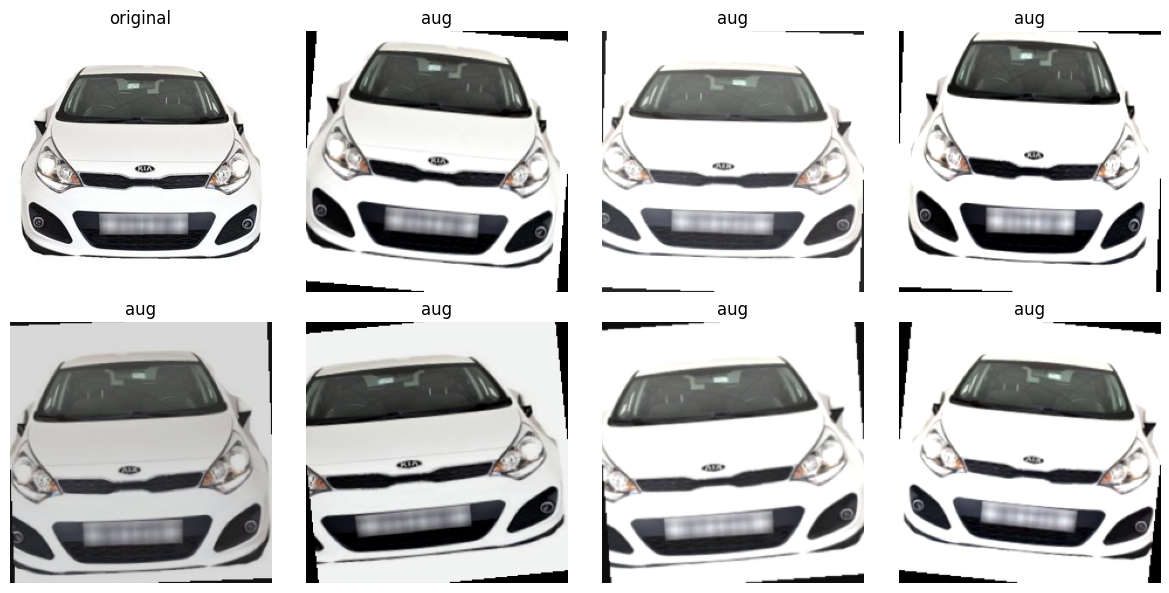

In [10]:
# Визуальная проверка: аугментации не должны "перекрашивать" машину

import matplotlib.pyplot as plt
from PIL import Image

def denorm(x):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (x.cpu()*std + mean).clamp(0,1)

img_path = train_df.sample(1, random_state=SEED)["path"].iloc[0]
img = Image.open(img_path).convert("RGB")

tfm_train = make_transforms(224, train=True)
tfm_eval  = make_transforms(224, train=False)

plt.figure(figsize=(12,6))
plt.subplot(2,4,1)
plt.imshow(img)
plt.axis("off")
plt.title("original")

for i in range(2,9):
    x = tfm_train(img)
    plt.subplot(2,4,i)
    plt.imshow(denorm(x).permute(1,2,0))
    plt.axis("off")
    plt.title("aug")

plt.tight_layout()
plt.show()


In [11]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import numpy as np
import os

class DVMColourDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tfm, return_path: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.tfm = tfm
        self.return_path = return_path

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        x = self.tfm(img)
        y = int(row["label"])
        if self.return_path:
            return x, y, row["path"]
        return x, y

def make_loaders(img_size: int, batch_size: int = 64, num_workers=None, use_sampler: bool = True):
    if num_workers is None:
        num_workers = max(2, min(8, (os.cpu_count() or 4) // 2))

    tr_ds = DVMColourDataset(train_df, make_transforms(img_size, True))
    tr_eval_ds = DVMColourDataset(train_df, make_transforms(img_size, False))
    va_ds = DVMColourDataset(val_df, make_transforms(img_size, False))
    te_ds = DVMColourDataset(test_df, make_transforms(img_size, False), return_path=True)

    if use_sampler:
        counts = np.bincount(train_df["label"].values, minlength=n_classes)
        weights = 1.0 / np.maximum(counts, 1)
        sample_w = weights[train_df["label"].values]
        sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
        tr_loader = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=True)
    else:
        tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    tr_eval_loader = DataLoader(tr_eval_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    te_loader = DataLoader(te_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return tr_loader, tr_eval_loader, va_loader, te_loader

IMG_SIZE = 224
BATCH_SIZE = 64

tr_loader, tr_eval_loader, va_loader, te_loader = make_loaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE, use_sampler=True)

batch = next(iter(tr_loader))
batch[0].shape, batch[1].shape


(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## 5) Train/Eval utilities (F1_macro)

Сохраняем лучший чекпоинт по `val_f1_macro`.

In [12]:
@torch.no_grad()
def eval_epoch(model, loader, max_batches=None):
    model.eval()
    ys, ps = [], []
    total_loss = 0.0
    total = 0
    correct = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        if len(batch) == 2:
            x, y = batch
        else:
            x, y, _ = batch

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * y.size(0)
        total += y.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()

        ys.append(y.cpu().numpy())
        ps.append(pred.cpu().numpy())

    ys = np.concatenate(ys) if ys else np.array([])
    ps = np.concatenate(ps) if ps else np.array([])

    f1 = f1_score(ys, ps, average="macro") if len(ys) else 0.0
    acc = correct / max(total, 1)
    return total_loss / max(total, 1), f1, acc

def train_model(
    model,
    tr_loader,
    tr_eval_loader,
    va_loader,
    epochs: int,
    lr: float,
    weight_decay: float = 1e-4,
    max_grad_norm: float = 1.0,
    label_smoothing: float = 0.0,
    mixed_precision: bool = True,
    train_metric_batches=60,  # сколько батчей считать для train_f1 (ускорение)
):
    model = model.to(device)

    # class weights для более честного macro-F1 при дисбалансе
    counts = np.bincount(train_df["label"].values, minlength=n_classes)
    class_w = (counts.sum() / np.maximum(counts, 1)).astype(np.float32)
    class_w = torch.tensor(class_w, device=device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type == "cuda"))

    best = {"f1": -1.0, "state": None, "epoch": -1}
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total = 0

        pbar = tqdm(tr_loader, desc=f"epoch {epoch}/{epochs}", leave=False)
        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
                logits = model(x)
                loss = F.cross_entropy(logits, y, weight=class_w, label_smoothing=label_smoothing)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item() * y.size(0)
            total += y.size(0)
            pbar.set_postfix(loss=float(loss.item()), lr=float(opt.param_groups[0]["lr"]))

        sched.step()

        tr_loss = total_loss / max(total, 1)
        tr_eval_loss, tr_f1, tr_acc = eval_epoch(model, tr_eval_loader, max_batches=train_metric_batches)
        va_loss, va_f1, va_acc = eval_epoch(model, va_loader)

        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_f1_macro": tr_f1,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "val_f1_macro": va_f1,
            "val_acc": va_acc,
        })

        if va_f1 > best["f1"]:
            best["f1"] = va_f1
            best["epoch"] = epoch
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"epoch={epoch:02d}  "
            f"train_loss={tr_loss:.4f} train_f1={tr_f1:.4f}  "
            f"val_loss={va_loss:.4f} val_f1={va_f1:.4f}  "
            f"best_val_f1={best['f1']:.4f} @ {best['epoch']}"
        )

    model.load_state_dict(best["state"])
    return model, pd.DataFrame(history), best

def plot_history(hist: pd.DataFrame, title: str):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,4))
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.title(title + " — loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(hist["epoch"], hist["train_f1_macro"], label="train_f1_macro")
    plt.plot(hist["epoch"], hist["val_f1_macro"], label="val_f1_macro")
    plt.title(title + " — F1_macro")
    plt.xlabel("epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6) Модель №1: ResNet18 *своими руками*


In [13]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.down = None
        if stride != 1 or in_ch != out_ch:
            self.down = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        if self.down is not None:
            identity = self.down(identity)
        out = F.relu(out + identity, inplace=True)
        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes):
        super().__init__()
        self.in_ch = 64
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _make_layer(self, block, out_ch, blocks, stride):
        layers = [block(self.in_ch, out_ch, stride=stride)]
        self.in_ch = out_ch * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.fc(x)
        return x

def resnet18_custom(num_classes: int):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)

scratch_model = resnet18_custom(n_classes)
sum(p.numel() for p in scratch_model.parameters()) / 1e6

11.181642

In [14]:
df.sample(20)[["path","brand","model","year","colour"]]


,path,brand,model,year,colour
11897,/home/jupyter/project/auto_dataset/confirmed_f...,BMW,X1,2009,Silver
29226,/home/jupyter/project/auto_dataset/confirmed_f...,Ford,EcoSport,2016,Silver
35263,/home/jupyter/project/auto_dataset/confirmed_f...,Jaguar,F-PACE,2017,Gray
12758,/home/jupyter/project/auto_dataset/confirmed_f...,BMW,X3,2011,Blue
23635,/home/jupyter/project/auto_dataset/confirmed_f...,Daihatsu,Terios,2003,Green
2320,/home/jupyter/project/auto_dataset/confirmed_f...,Audi,TT,2009,Black
29562,/home/jupyter/project/auto_dataset/confirmed_f...,Ford,Focus,2016,Blue
49683,/home/jupyter/project/auto_dataset/confirmed_f...,Porsche,Panamera,2015,Gray
42894,/home/jupyter/project/auto_dataset/confirmed_f...,Mercedes-Benz,S Class,2013,Gray
45955,/home/jupyter/project/auto_dataset/confirmed_f...,Nissan,Juke,2014,Yellow


/tmp/ipykernel_11411/1580134724.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type == "cuda"))
epoch 1/15:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=01  train_loss=0.7597 train_f1=0.3128  val_loss=2.0869 val_f1=0.3089  best_val_f1=0.3089 @ 1


epoch 2/15:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=02  train_loss=0.5010 train_f1=0.3884  val_loss=2.0338 val_f1=0.3887  best_val_f1=0.3887 @ 2


epoch 3/15:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


...

epoch=13  train_loss=0.0475 train_f1=0.8706  val_loss=0.4457 val_f1=0.8196  best_val_f1=0.8196 @ 13


epoch 14/15:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=14  train_loss=0.0455 train_f1=0.8823  val_loss=0.4342 val_f1=0.8291  best_val_f1=0.8291 @ 14


epoch 15/15:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=15  train_loss=0.0419 train_f1=0.8791  val_loss=0.4320 val_f1=0.8279  best_val_f1=0.8291 @ 14
custom_resnet18: best {'f1': 0.8291309206798292, 'state': {'stem.0.weight': tensor([[[[ 8.5244e-03,  8.9771e-03, -4.5966e-02,  ..., -5.1109e-02,
            1.6467e-03, -4.2475e-02],
          [-1.9123e-02,  2.7007e-03,  1.4816e-03,  ...,  2.0496e-02,
           -6.8233e-03,  4.1177e-02],
          [-2.3564e-02, -2.8968e-02, -2.5809e-02,  ..., -4.0184e-02,
           -1.0844e-02,  3.8050e-03],
          ...,
          [ 1.9894e-02,  1.3921e-03, -2.1339e-02,  ...,  2.1830e-02,
           -3.3556e-02, -9.6111e-03],
          [-3.8614e-02,  2.7401e-02,  3.2777e-02,  ...,  9.3020e-03,
            2.4595e-02, -3.9236e-02],
          [-3.4054e-02,  4.7172e-02, -2.9138e-02,  ..., -5.5621e-02,
           -2.8757e-02,  2.8046e-02]],

         [[ 2.0779e-02,  3.5818e-02, -1.1617e-03,  ..., -4.2750e-02,
           -3.1971e-02, -3.0903e-02],
          [ 3.3795e-03, -1.5729e-02,  4.1203e-02,  ...,  1

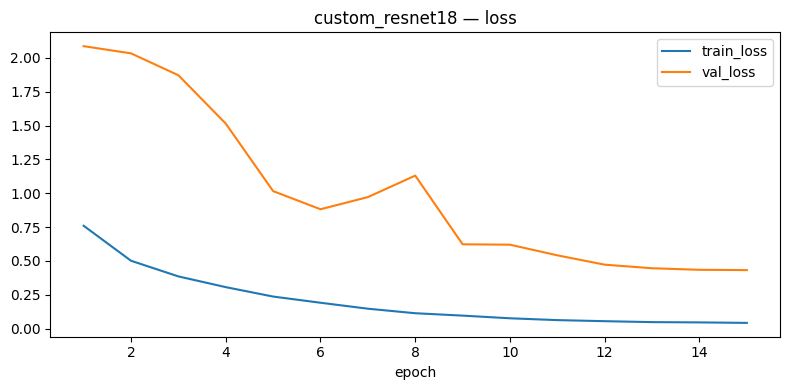

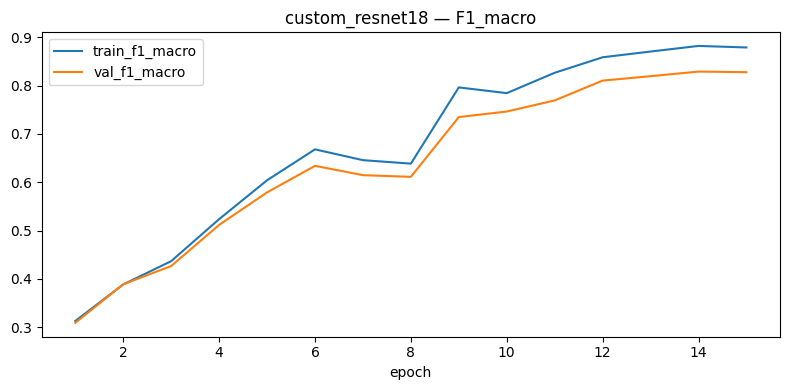

In [15]:
import time

t0 = time.time()
scratch_model, scratch_hist, scratch_best = train_model(
    scratch_model, tr_loader, tr_eval_loader, va_loader,
    epochs=15,
    lr=3e-4,
    weight_decay=1e-4,
    label_smoothing=0.0,
    mixed_precision=True,
)
t1 = time.time()

print("custom_resnet18: best", scratch_best)
print("train time (min):", (t1 - t0) / 60)

plot_history(scratch_hist, "custom_resnet18")


In [16]:
te_loss, te_f1, te_acc = eval_epoch(scratch_model, te_loader)
print("custom_resnet18  test_loss=", te_loss, " test_f1_macro=", te_f1, " test_acc=", te_acc)


custom_resnet18  test_loss= 0.44094225205321824  test_f1_macro= 0.8214081549837158  test_acc= 0.859976064284493


## 7) Модель №2: ResNet50 pretrained (ImageNet) → fine-tune

In [17]:
import torchvision

def resnet50_pretrained(num_classes: int):
    m = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
    in_f = m.fc.in_features
    m.fc = nn.Linear(in_f, num_classes)
    return m

resnet50_model = resnet50_pretrained(n_classes)
sum(p.numel() for p in resnet50_model.parameters()) / 1e6

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /tmp/xdg_cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 65.4MB/s]


23.528522

/tmp/ipykernel_11411/1580134724.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type == "cuda"))
epoch 1/2:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=01  train_loss=0.6668 train_f1=0.4822  val_loss=1.4759 val_f1=0.4738  best_val_f1=0.4738 @ 1


epoch 2/2:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=02  train_loss=0.4805 train_f1=0.4892  val_loss=1.4795 val_f1=0.4784  best_val_f1=0.4784 @ 2


/tmp/ipykernel_11411/1580134724.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type == "cuda"))
epoch 1/6:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


...

epoch=04  train_loss=0.0381 train_f1=0.9161  val_loss=0.3422 val_f1=0.8676  best_val_f1=0.8676 @ 4


epoch 5/6:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=05  train_loss=0.0259 train_f1=0.9245  val_loss=0.3394 val_f1=0.8747  best_val_f1=0.8747 @ 5


epoch 6/6:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=06  train_loss=0.0204 train_f1=0.9561  val_loss=0.2872 val_f1=0.8917  best_val_f1=0.8917 @ 6
resnet50: best {'f1': 0.8916826245081317, 'state': {'conv1.weight': tensor([[[[-4.9990e-03, -3.2836e-03,  3.9121e-02,  ...,  4.8193e-02,
           -1.5392e-02,  1.0406e-02],
          [-5.7129e-02,  4.4523e-02,  7.7650e-02,  ...,  8.1680e-02,
            2.9610e-02, -6.0310e-02],
          [ 6.9396e-02, -2.6822e-01,  4.0728e-01,  ..., -1.7598e-01,
            2.1317e-01, -7.4022e-02],
          ...,
          [-1.0855e-01,  3.7817e-01, -4.5695e-01,  ...,  6.7766e-01,
           -5.8264e-01,  2.2629e-01],
          [ 2.3574e-02, -1.7932e-01,  6.4356e-01,  ...,  5.2229e-01,
           -5.4651e-02, -7.1733e-02],
          [ 4.7327e-02, -1.2635e-01,  2.0759e-02,  ..., -3.6002e-01,
            1.8708e-01, -2.6398e-02]],

         [[ 1.6119e-02,  1.0438e-02, -8.1421e-03,  ...,  9.0682e-02,
           -5.7527e-02,  2.1236e-02],
          [-2.7358e-02,  4.4833e-02,  9.2695e-02,  ...,  1.1508e-01

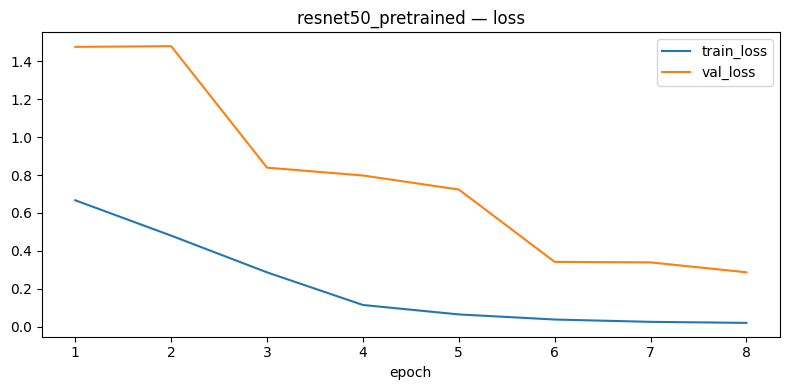

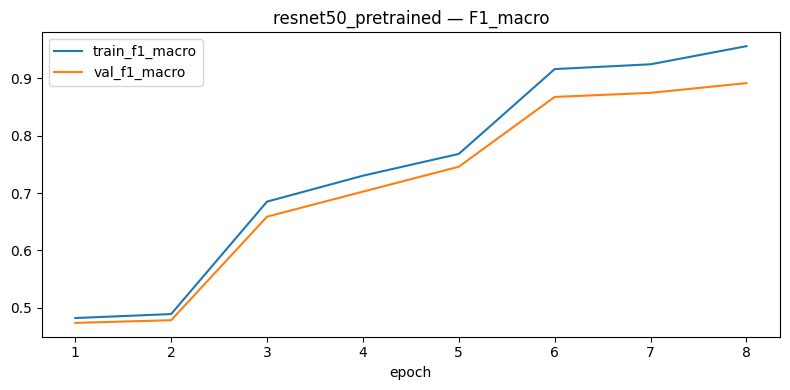

In [ ]:
def freeze_backbone_resnet(m: nn.Module, freeze: bool = True):
    for name, p in m.named_parameters():
        if name.startswith("fc."):
            p.requires_grad = True
        else:
            p.requires_grad = (not freeze)

# Fine-tuning стратегия:
# 1) "warmup head": замораживаем backbone и учим только классификатор (быстро и стабильно)
# 2) full fine-tune: размораживаем всё и дообучаем с меньшим lr

import time

freeze_backbone_resnet(resnet50_model, True)

t0 = time.time()
resnet50_model, resnet50_hist_1, resnet50_best_1 = train_model(
    resnet50_model, tr_loader, tr_eval_loader, va_loader,
    epochs=2,
    lr=2e-3,
    weight_decay=1e-4,
    mixed_precision=True,
)
freeze_backbone_resnet(resnet50_model, False)

resnet50_model, resnet50_hist_2, resnet50_best_2 = train_model(
    resnet50_model, tr_loader, tr_eval_loader, va_loader,
    epochs=6,
    lr=5e-4,
    weight_decay=1e-4,
    mixed_precision=True,
)
t1 = time.time()

# объединяем истории для графиков
resnet50_hist = pd.concat([
    resnet50_hist_1,
    resnet50_hist_2.assign(epoch=resnet50_hist_2["epoch"] + resnet50_hist_1["epoch"].max()),
], ignore_index=True)

print("resnet50: best", resnet50_best_2)
print("train time (min):", (t1 - t0) / 60)
plot_history(resnet50_hist, "resnet50_pretrained")


In [ ]:
te_loss, te_f1, te_acc = eval_epoch(resnet50_model, te_loader)
print("resnet50_pretrained  test_loss=", te_loss, " test_f1_macro=", te_f1, " test_acc=", te_acc)


resnet50_pretrained  test_loss= 0.2758538791829245  test_f1_macro= 0.8937064057204502  test_acc= 0.9252863737391007


## 8) Модель №3: MobileNetV3-Large pretrained (ImageNet) → fine-tune

In [ ]:
# MobileNetV3-Large (ImageNet pretrained) — быстрая и лёгкая модель

def mobilenet_v3_large_pretrained(num_classes: int):
    m = torchvision.models.mobilenet_v3_large(weights=torchvision.models.MobileNet_V3_Large_Weights.DEFAULT)
    in_f = m.classifier[3].in_features
    m.classifier[3] = nn.Linear(in_f, num_classes)
    return m

mobv3_model = mobilenet_v3_large_pretrained(n_classes)
sum(p.numel() for p in mobv3_model.parameters()) / 1e6


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /tmp/xdg_cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 41.6MB/s]


4.214842

/tmp/ipykernel_11411/1580134724.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type == "cuda"))
epoch 1/2:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=01  train_loss=0.5418 train_f1=0.5084  val_loss=1.6219 val_f1=0.4783  best_val_f1=0.4783 @ 1


epoch 2/2:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):
/tmp/ipykernel_11411/1580134724.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type == "cuda"))


epoch=02  train_loss=0.2683 train_f1=0.5699  val_loss=1.2406 val_f1=0.5420  best_val_f1=0.5420 @ 2


epoch 1/6:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


...

epoch=04  train_loss=0.0322 train_f1=0.9362  val_loss=0.3388 val_f1=0.8678  best_val_f1=0.8678 @ 4


epoch 5/6:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=05  train_loss=0.0238 train_f1=0.9490  val_loss=0.2936 val_f1=0.8877  best_val_f1=0.8877 @ 5


epoch 6/6:   0%|          | 0/732 [00:00<?, ?it/s]/tmp/ipykernel_11411/1580134724.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler.is_enabled()):


epoch=06  train_loss=0.0199 train_f1=0.9623  val_loss=0.2683 val_f1=0.9015  best_val_f1=0.9015 @ 6
mobv3: best {'f1': 0.901492361134892, 'state': {'features.0.0.weight': tensor([[[[ 6.0937e-03, -2.7906e-02,  9.4395e-02],
          [-1.1428e-01,  2.1134e-01,  5.6981e-01],
          [-7.9085e-02, -5.4893e-02,  2.5686e-01]],

         [[ 1.6187e-01,  6.9372e-02,  2.0665e-01],
          [-6.7045e-03,  1.8381e-01,  5.3181e-01],
          [ 1.3300e-01,  1.3139e-01,  5.4226e-01]],

         [[-1.9909e-03, -2.5264e-02, -5.9632e-02],
          [-1.6517e-01,  8.6491e-02,  1.8928e-01],
          [-8.5922e-02, -6.1452e-02,  8.3728e-02]]],


        [[[-2.2920e-01,  5.2842e-02,  5.3043e-02],
          [-4.3955e-02,  1.2248e+00, -1.0718e+00],
          [ 4.0918e-02,  1.7070e+00, -1.7555e+00]],

         [[-4.5527e-01,  2.1669e-01, -6.8661e-02],
          [-4.8333e-02,  2.2671e+00, -2.0205e+00],
          [ 1.8747e-01,  2.7480e+00, -2.8498e+00]],

         [[-8.5204e-02,  5.5303e-02,  4.4564e-02],
  

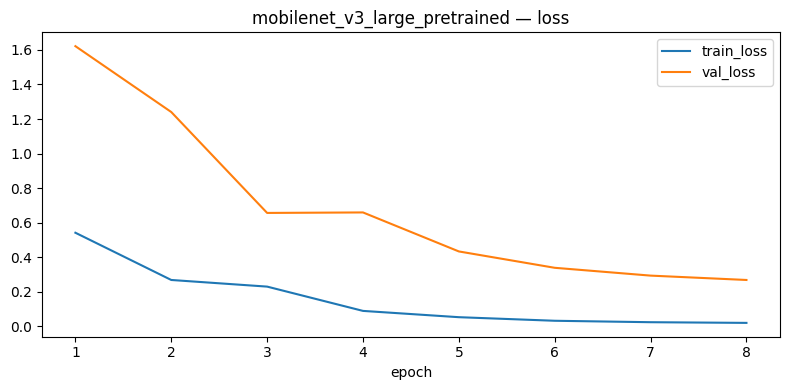

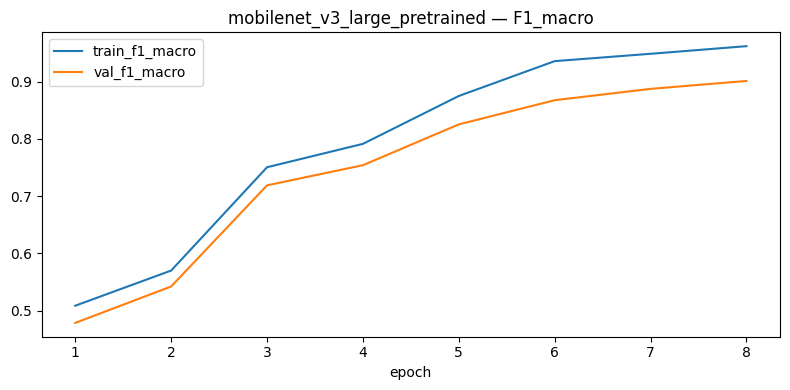

In [ ]:
def freeze_backbone_mobv3(m: nn.Module, freeze: bool = True):
    for name, p in m.named_parameters():
        if name.startswith("classifier."):
            p.requires_grad = True
        else:
            p.requires_grad = (not freeze)

import time

freeze_backbone_mobv3(mobv3_model, True)

t0 = time.time()
mobv3_model, mobv3_hist_1, mobv3_best_1 = train_model(
    mobv3_model, tr_loader, tr_eval_loader, va_loader,
    epochs=2,
    lr=2e-3,
    weight_decay=1e-4,
    mixed_precision=True,
)

freeze_backbone_mobv3(mobv3_model, False)

mobv3_model, mobv3_hist_2, mobv3_best_2 = train_model(
    mobv3_model, tr_loader, tr_eval_loader, va_loader,
    epochs=6,
    lr=6e-4,
    weight_decay=1e-4,
    mixed_precision=True,
)
t1 = time.time()

mobv3_hist = pd.concat([
    mobv3_hist_1,
    mobv3_hist_2.assign(epoch=mobv3_hist_2["epoch"] + mobv3_hist_1["epoch"].max()),
], ignore_index=True)

print("mobv3: best", mobv3_best_2)
print("train time (min):", (t1 - t0) / 60)
plot_history(mobv3_hist, "mobilenet_v3_large_pretrained")


In [ ]:
te_loss, te_f1, te_acc = eval_epoch(mobv3_model, te_loader)
print("mobilenet_v3_large_pretrained  test_loss=", te_loss, " test_f1_macro=", te_f1, " test_acc=", te_acc)


mobilenet_v3_large_pretrained  test_loss= 0.26527796329025694  test_f1_macro= 0.8875513508009336  test_acc= 0.9263121901179688


## 9) Сравнение моделей + отчёт и вывод

In [25]:
@torch.no_grad()
def predict_labels(model, loader, max_batches=None):
    model.eval()
    ys, ps, paths = [], [], []
    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        if len(batch) == 2:
            x, y = batch
            pths = None
        else:
            x, y, pths = batch

        x = x.to(device, non_blocking=True)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()

        ys.append(y.numpy())
        ps.append(pred)
        if pths is not None:
            paths += list(pths)

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred, paths

def eval_all_splits(model):
    tr_loss, tr_f1, tr_acc = eval_epoch(model, tr_eval_loader)
    va_loss, va_f1, va_acc = eval_epoch(model, va_loader)
    te_loss, te_f1, te_acc = eval_epoch(model, te_loader)
    return {
        "train_loss": tr_loss, "train_f1_macro": tr_f1, "train_acc": tr_acc,
        "val_loss": va_loss, "val_f1_macro": va_f1, "val_acc": va_acc,
        "test_loss": te_loss, "test_f1_macro": te_f1, "test_acc": te_acc,
    }

models = {
    "custom_resnet18": scratch_model,
    "resnet50_pretrained": resnet50_model,
    "mobilenet_v3_large_pretrained": mobv3_model,
}

results = []
test_preds = {}

for name, model in models.items():
    m = model.to(device)
    metrics = eval_all_splits(m)
    metrics["model"] = name
    results.append(metrics)

    y_true, y_pred, paths = predict_labels(m, te_loader)
    test_preds[name] = (y_true, y_pred, paths)

results_df = pd.DataFrame(results).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
display(results_df)

print("\nТребование: F1_macro > 0.8 на test (у лучшей модели)")
print("best test_f1_macro:", results_df.iloc[0]["test_f1_macro"])


,train_loss,train_f1_macro,train_acc,val_loss,val_f1_macro,val_acc,test_loss,test_f1_macro,test_acc,model
0,0.155099,0.951093,0.952598,0.287194,0.891683,0.921525,0.275854,0.893706,0.925286,resnet50_pretrained
1,0.146171,0.960446,0.955611,0.268324,0.901492,0.927509,0.265278,0.887551,0.926312,mobilenet_v3_large_pretrained
2,0.348788,0.880161,0.881858,0.434163,0.829131,0.861344,0.440942,0.821408,0.859976,custom_resnet18



Требование: F1_macro > 0.8 на test (у лучшей модели)
best test_f1_macro: 0.8937064057204502


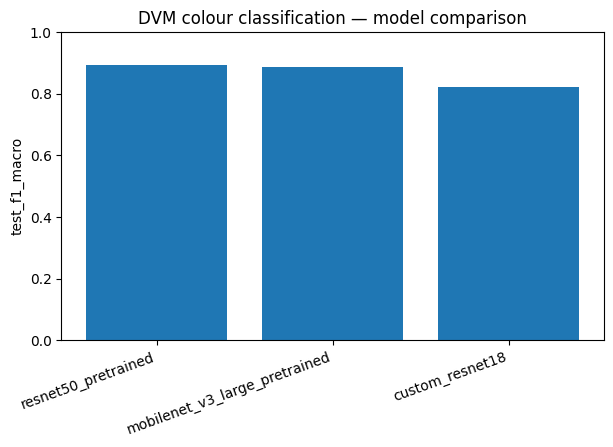

Best: resnet50_pretrained | test_f1_macro=0.8937


In [27]:
import matplotlib.pyplot as plt

metric_col = "test_f1_macro"
if metric_col not in results_df.columns:
    metric_col = next((c for c in ["f1_macro_test", "f1_macro", "test_f1", "f1_test"] if c in results_df.columns), None)
if metric_col is None:
    raise KeyError(f"Не нашёл колонку с macro-F1. Колонки: {list(results_df.columns)}")

plot_df = results_df.sort_values(metric_col, ascending=False).reset_index(drop=True)

plt.figure(figsize=(7, 4))
plt.bar(plot_df["model"], plot_df[metric_col])
plt.ylim(0, 1.0)
plt.ylabel(f"{metric_col}")
plt.xticks(rotation=20, ha="right")
plt.title("DVM colour classification — model comparison")
plt.show()

best_f1 = float(plot_df.loc[0, metric_col])
best_model = plot_df.loc[0, "model"]
print(f"Best: {best_model} | {metric_col}={best_f1:.4f}")

if best_f1 < 0.80:
    print("\n⚠️ Ниже 0.8. Что попробовать:")
    print("- увеличить epochs (особенно для custom),")
    print("- уменьшить lr при full fine-tune,")
    print("- усилить балансировку (sampler/weights),")
    print("- проверить, что train/val/test стратифицированы и нет утечки,")
    print("- если классы редкие портят macro-F1 — повышать MIN_SAMPLES_PER_CLASS или оставлять top-K классов.")

MODEL: resnet50_pretrained
Test metrics: f1_macro= 0.8937064057204502 acc= 0.9252863737391007

Classification report (test):
              precision    recall  f1-score   support

       Black     0.9440    0.9295    0.9367      1432
        Gray     0.8530    0.8765    0.8646       947
       White     0.9827    0.9691    0.9759       939
        Blue     0.9349    0.9305    0.9327       849
      Silver     0.9147    0.8829    0.8985       777
         Red     0.9886    0.9951    0.9918       610
       Brown     0.6607    0.8132    0.7291        91
       Green     0.8333    0.8974    0.8642        78
      Yellow     0.9552    0.9697    0.9624        66
       Beige     0.7353    0.8333    0.7812        60

    accuracy                         0.9253      5849
   macro avg     0.8802    0.9097    0.8937      5849
weighted avg     0.9270    0.9253    0.9259      5849



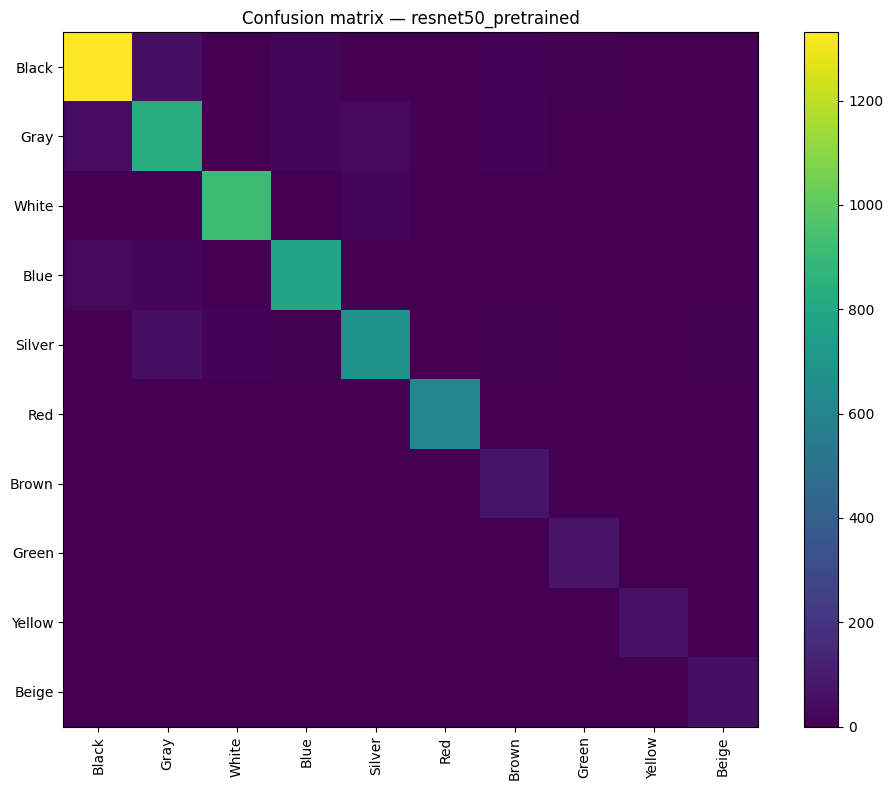

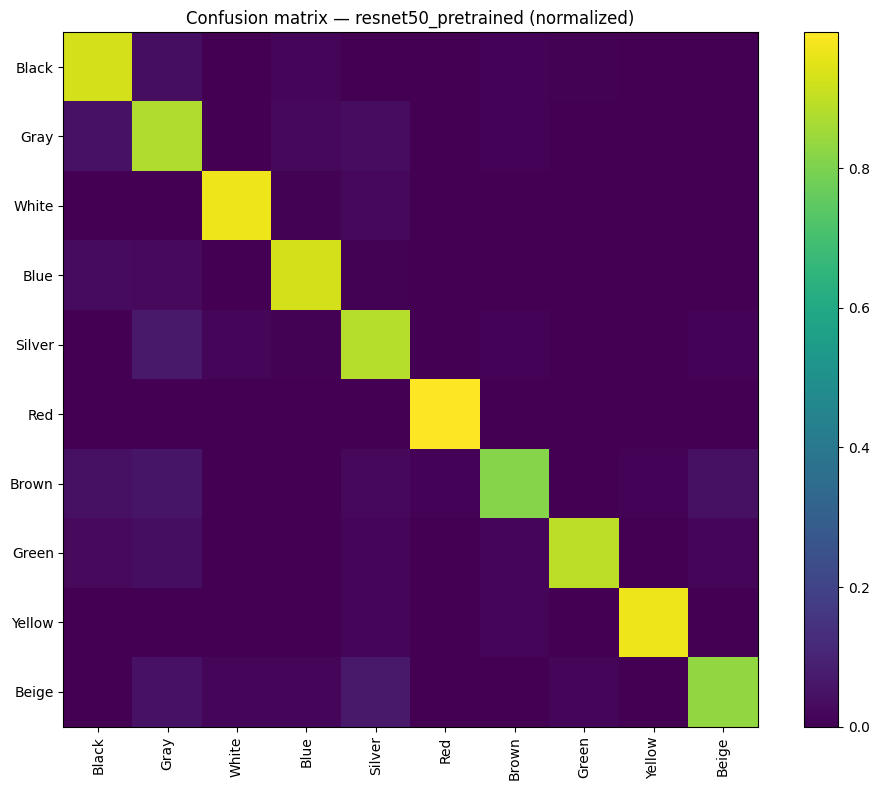

MODEL: mobilenet_v3_large_pretrained
Test metrics: f1_macro= 0.8875513508009336 acc= 0.9263121901179688

Classification report (test):
              precision    recall  f1-score   support

       Black     0.9423    0.9246    0.9334      1432
        Gray     0.8462    0.8775    0.8616       947
       White     0.9786    0.9734    0.9760       939
        Blue     0.9632    0.9246    0.9435       849
      Silver     0.9051    0.9202    0.9126       777
         Red     0.9854    0.9951    0.9902       610
       Brown     0.6531    0.7033    0.6772        91
       Green     0.8571    0.8462    0.8516        78
      Yellow     0.9412    0.9697    0.9552        66
       Beige     0.7500    0.8000    0.7742        60

    accuracy                         0.9263      5849
   macro avg     0.8822    0.8935    0.8876      5849
weighted avg     0.9275    0.9263    0.9268      5849



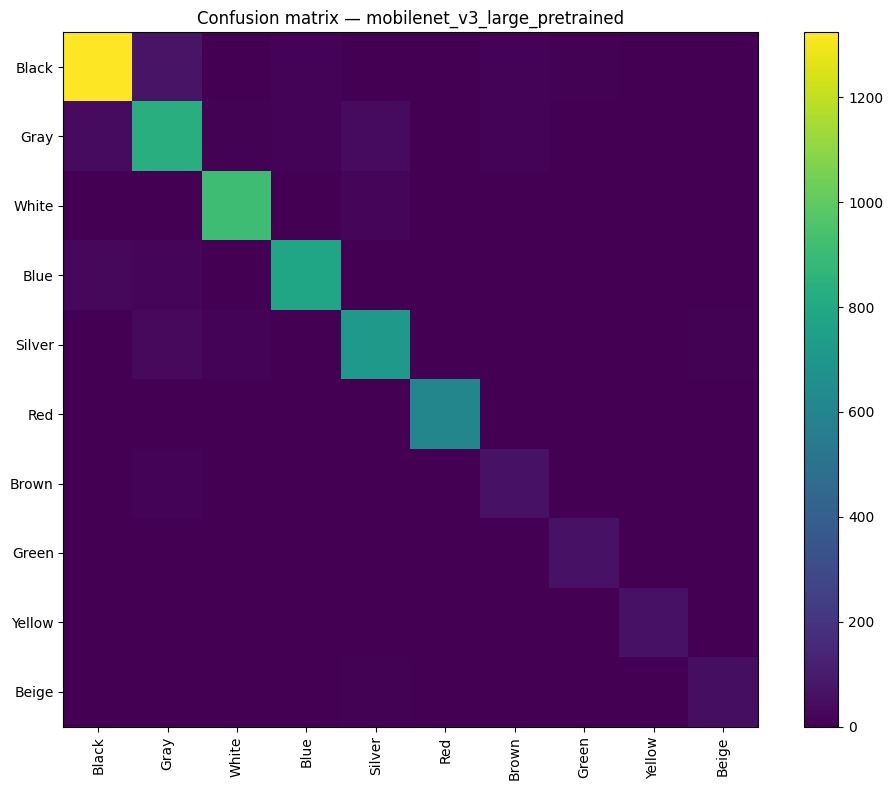

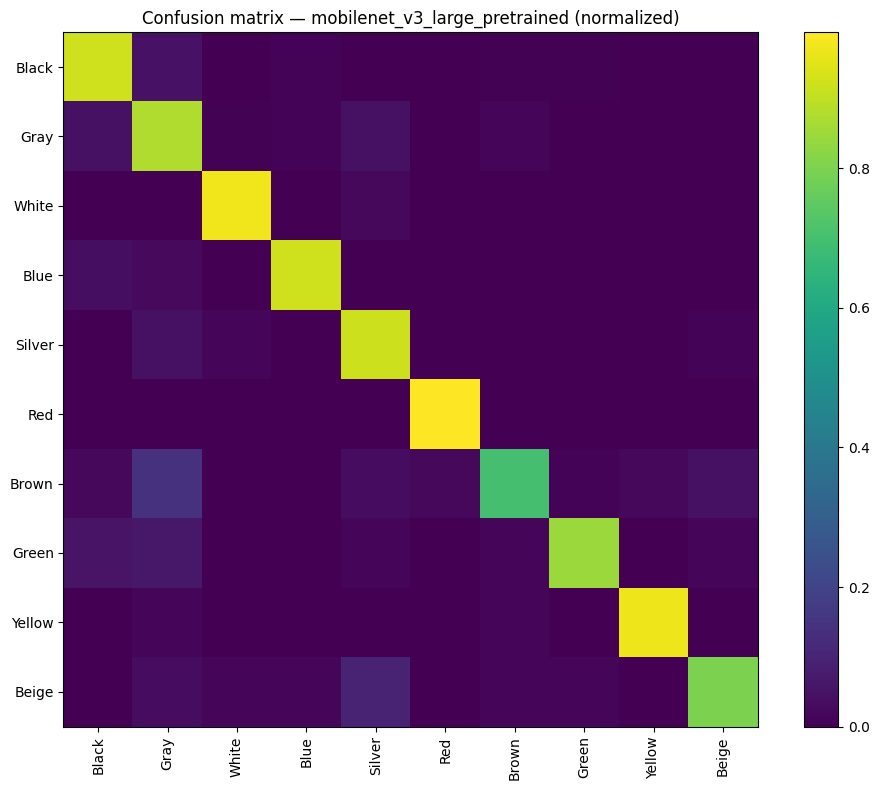

MODEL: custom_resnet18
Test metrics: f1_macro= 0.8214081549837158 acc= 0.859976064284493

Classification report (test):
              precision    recall  f1-score   support

       Black     0.9260    0.7954    0.8557      1432
        Gray     0.7139    0.8194    0.7630       947
       White     0.9431    0.9361    0.9396       939
        Blue     0.8783    0.8587    0.8684       849
      Silver     0.8380    0.8520    0.8449       777
         Red     0.9934    0.9902    0.9918       610
       Brown     0.5603    0.7143    0.6280        91
       Green     0.5965    0.8718    0.7083        78
      Yellow     0.9552    0.9697    0.9624        66
       Beige     0.5867    0.7333    0.6519        60

    accuracy                         0.8600      5849
   macro avg     0.7991    0.8541    0.8214      5849
weighted avg     0.8696    0.8600    0.8624      5849



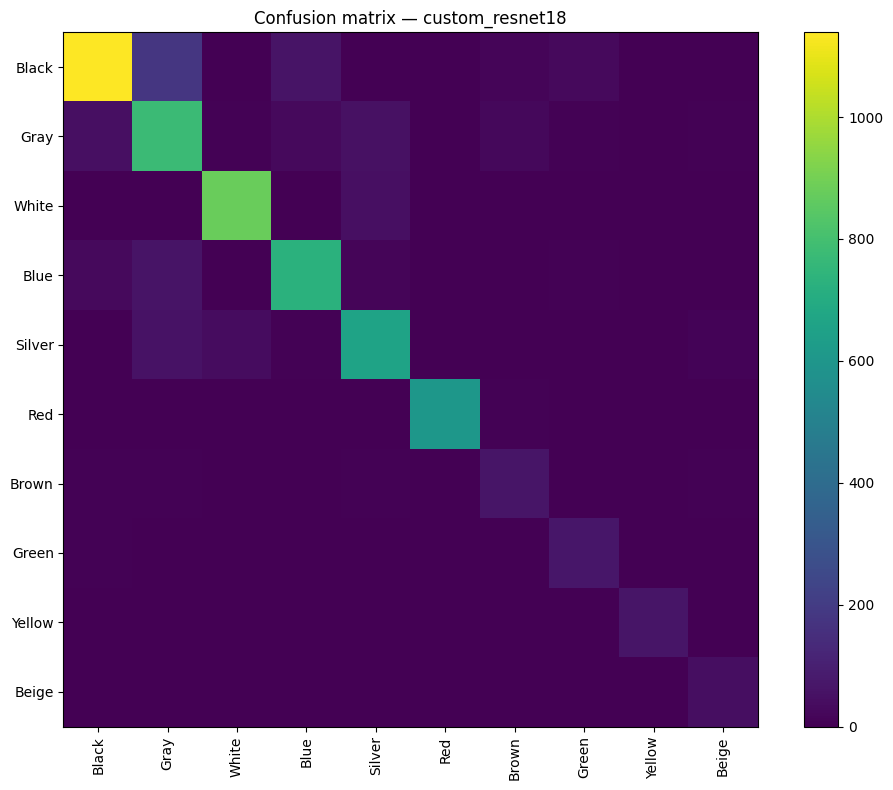

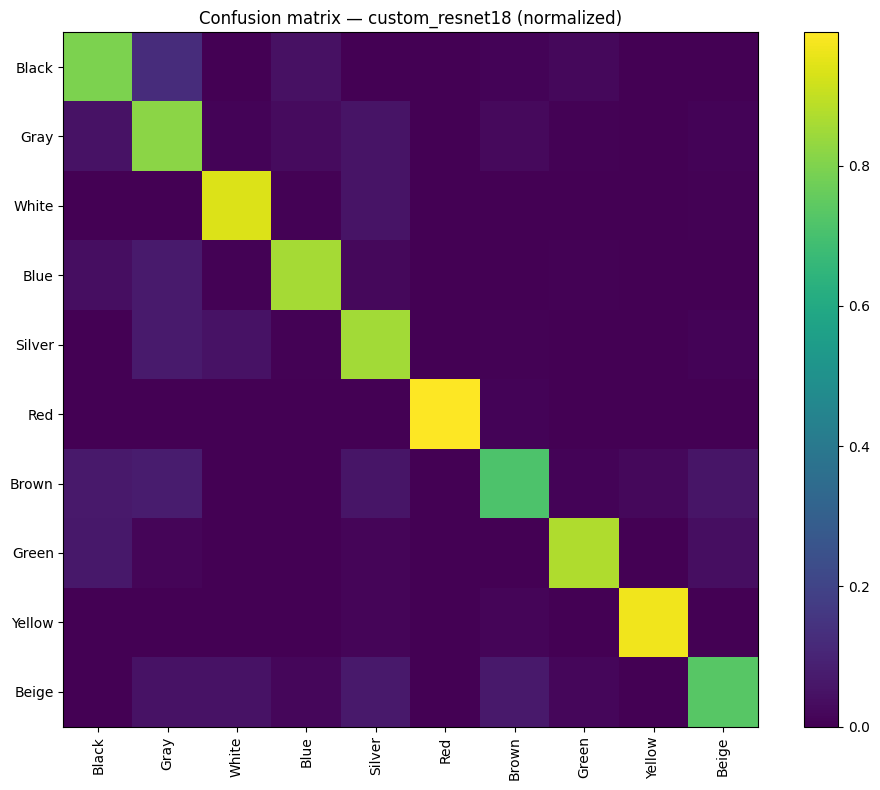

In [28]:
import matplotlib.pyplot as plt

def plot_cm(cm, labels, title: str, normalize: bool = False):
    if normalize:
        cm = cm.astype(np.float32)
        cm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(10,8))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title + (" (normalized)" if normalize else ""))
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

labels = [id2colour[i] for i in range(n_classes)]

for name in results_df["model"].tolist():
    y_true, y_pred, _ = test_preds[name]
    print("="*90)
    print("MODEL:", name)
    print("Test metrics:",
          "f1_macro=", f1_score(y_true, y_pred, average="macro"),
          "acc=", (y_true == y_pred).mean())
    print("\nClassification report (test):")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    plot_cm(cm, labels, f"Confusion matrix — {name}", normalize=False)
    plot_cm(cm, labels, f"Confusion matrix — {name}", normalize=True)


Best model by test_f1_macro: resnet50_pretrained


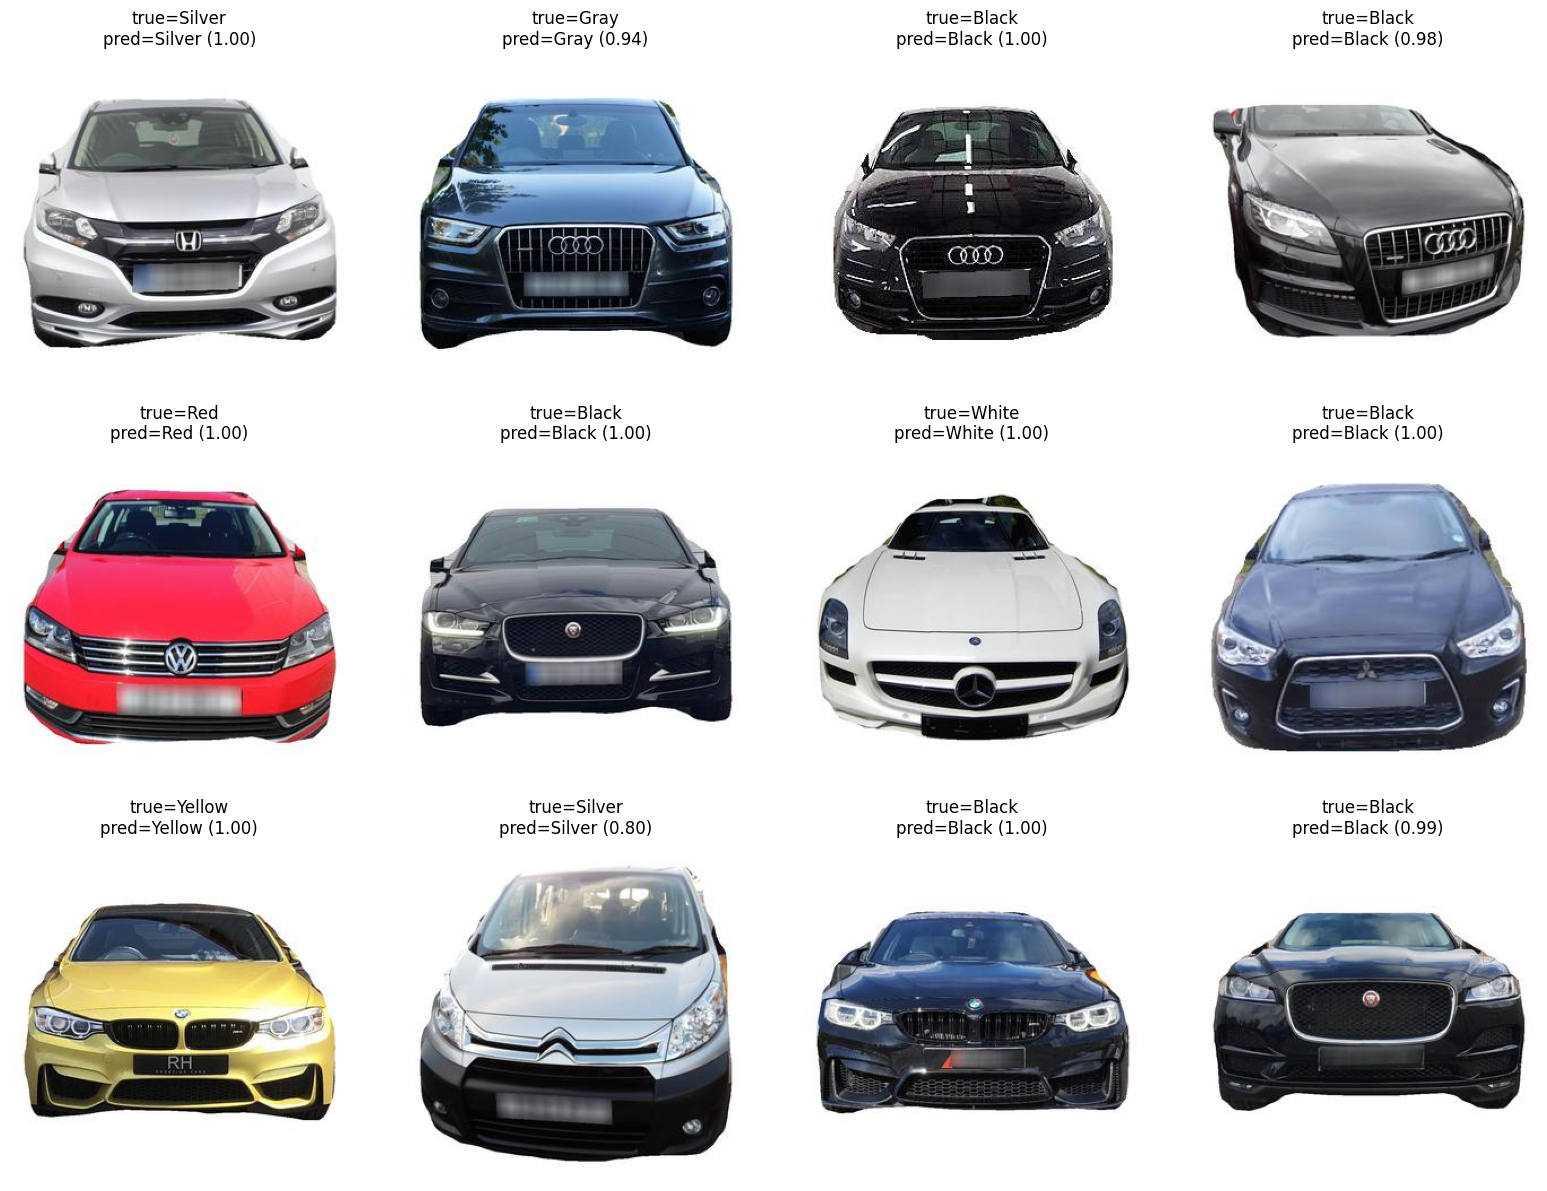

In [29]:
# --- Демо инференса "руками" ---
# Показываем исходную картинку (без аугментаций), истинный класс и предсказание модели.

from PIL import Image
import matplotlib.pyplot as plt
import torch

best_name = results_df.iloc[0]["model"]
best_model = models[best_name].to(device).eval()
print("Best model by test_f1_macro:", best_name)

eval_tfm = make_transforms(224, train=False)

@torch.no_grad()
def predict_one(path: str):
    img = Image.open(path).convert("RGB")
    x = eval_tfm(img).unsqueeze(0).to(device)
    logits = best_model(x)
    prob = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred = int(prob.argmax())
    return pred, float(prob[pred])

def show_inference(frame: pd.DataFrame, n: int = 12):
    sample = frame.sample(n=min(n, len(frame)), random_state=SEED).reset_index(drop=True)
    cols = 4
    rows = (len(sample) + cols - 1) // cols
    plt.figure(figsize=(cols*4, rows*4))
    for i, r in sample.iterrows():
        path = r["path"]
        true = int(r["label"])
        pred, p = predict_one(path)

        img = Image.open(path).convert("RGB")
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"true={id2colour[true]}\npred={id2colour[pred]} ({p:.2f})")
    plt.tight_layout()
    plt.show()

show_inference(test_df, n=12)


### Вывод

- Мы обучили **3 модели** (1 from-scratch + 2 pretrained) на одинаковом **train/val/test** распределении цветов.
- Лучшей моделью по **test F1_macro** оказалась: **(см. `results_df` выше)**.
- Fine-tune (ImageNet) обычно выигрывает у обучения с нуля по двум причинам:
  1) backbone уже содержит универсальные признаки (границы, текстуры, формы),
  2) на сравнительно небольшом датасете быстрее сходится и меньше переобучается.
- Самописный ResNet18 тоже способен показать достойное качество, но обычно требует:
  - больше эпох / аккуратнее lr schedule,
  - работы с дисбалансом (sampler/weights),
  - аккуратных аугментаций.

**Анализ ошибок:**
- По confusion matrix видно, какие цвета путаются чаще всего (например, `Gray`↔`Silver`, `Blue`↔`Black` при тёмном освещении).
- Именно поэтому мы используем умеренный `ColorJitter` (без hue), чтобы модель была устойчивее к освещению, но не “училась на перекрашивании”.

**Критерий лабы:** `F1_macro > 0.8` на test — проверяется в `results_df`.
